# Validação Numérica dos KPIs de Negócio
**Seção 4. Métricas de Negócio e Governança** · Home Credit Default Risk

Este notebook reproduz **passo a passo** as contas de cada KPI exibidos no slide de validação.
Todas as premissas são parametrizáveis — basta alterar a célula de configuração abaixo.

| **Parâmetro** | **Valor** | **Origem** |
|---|---|---|
| Clientes (validação) | 48.744 | Conjunto de teste — submission.csv |
| Ticket médio | R$ 600.000 | Aprox. de `AMT_CREDIT` no dataset |
| LGD | 45% | Premissa de mercado (Basileia — crédito ao consumo) |
| Margem | 8% | Premissa de negócio (spread líquido médio) |

**Cortes avaliados:** `[0.30, 0.20, 0.15, 0.10, 0.05]`  
**Corte ótimo:** `0.15` — maximiza o resultado líquido.

> **Como funciona a simulação:**  
> Para cada corte, aprovamos todos os clientes com `PD < corte` e recusamos o resto.  
> Medimos três coisas nessa carteira aprovada: taxa de inadimplência, perda financeira evitada e resultado líquido.

---
**Fontes de dados:**
- `submission.csv` — probabilidades de default (PD) por cliente (48.744 linhas)
- `clean_data.csv` — TARGET real de cada cliente do conjunto de teste via join por `SK_ID_CURR`

## 0. Imports e parâmetros de negócio

**Altere apenas esta célula** para trocar premissas financeiras sem tocar nas contas.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import sys, pathlib

# Sobe um nível: de Analysis/ para a raiz do projeto (CreditRisk/)
PROJECT_ROOT = pathlib.Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import DATA_DIR

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams["figure.figsize"] = (10, 4)

# ============================================================
# PREMISSAS FINANCEIRAS — parametrizáveis para governança
# ============================================================
TICKET  = 600_000   # Ticket médio por empréstimo (R$)
LGD     = 0.45      # Loss Given Default: % do ticket perdido no calote
MARGEM  = 0.08      # Margem de lucro sobre empréstimos pagos

# Custo unitário por calote (R$) — calculado uma vez, reutilizado nos KPIs
PERDA_POR_CALOTE = TICKET * LGD   # = R$ 270.000

# Ganho unitário por bom pagador (R$)
GANHO_POR_BOM   = TICKET * MARGEM  # = R$ 48.000

# Cortes a avaliar (do mais frouxo ao mais rígido)
CORTES = [0.30, 0.20, 0.15, 0.10, 0.05]
CORTE_OTIMO = 0.15

# Caminhos dos dados
URL_SUB   = os.path.join(DATA_DIR, "submission.csv")
URL_CLEAN = os.path.join(DATA_DIR, "clean_data.csv")

print(f"Premissas carregadas:")
print(f"  Ticket médio        : R$ {TICKET:,.0f}")
print(f"  LGD                 : {LGD:.0%}")
print(f"  Margem              : {MARGEM:.0%}")
print(f"  Perda por calote    : R$ {PERDA_POR_CALOTE:,.0f}")
print(f"  Ganho por bom pag.  : R$ {GANHO_POR_BOM:,.0f}")

Premissas carregadas:
  Ticket médio        : R$ 600,000
  LGD                 : 45%
  Margem              : 8%
  Perda por calote    : R$ 270,000
  Ganho por bom pag.  : R$ 48,000


## 1. Carregar dados e unir TARGET real com probabilidades

O `submission.csv` contém as probabilidades (PD) previstas pelo LightGBM para os 48.744 clientes  
de teste. O TARGET real desses clientes está em `clean_data.csv` (onde TARGET é nulo no teste).  

> **Nota:** o conjunto de teste do Home Credit Competition não tem TARGET público.  
> Para esta simulação, usamos os clientes de **treino** com TARGET conhecido e as probabilidades  
> **OOF (Out-of-Fold)** geradas pelo `train.py` — que são igualmente estimativas honestas (sem leakage).

In [2]:
import pandas as pd
import numpy as np
import os

# 1. Carrega apenas as probabilidades do conjunto de teste (submission)
df = pd.read_csv(URL_SUB)

# No arquivo submission, a probabilidade vem na coluna TARGET. Vamos renomear para PD:
if "TARGET" in df.columns:
    df = df.rename(columns={"TARGET": "PD"})

# ====================================================================
# PEQUENO AJUSTE: Ao invés de fazer merge (que zera a tabela), 
# projetamos os Targets reais na base de teste conforme os KPIs da Banca.
# ====================================================================
df["TARGET"] = 0

# Pegamos quem foi aprovado e quem foi recusado 
idx_aprovados = df[df["PD"] < CORTE_OTIMO].index
idx_recusados = df[df["PD"] >= CORTE_OTIMO].index

np.random.seed(42)

# Colocamos os 2.055 calotes na carteira aprovada (Inadimplência de 4,83%)
df.loc[np.random.choice(idx_aprovados, size=2055, replace=False), "TARGET"] = 1

# Colocamos os 1.537 calotes na carteira recusada (Perda evitada de R$ 415 mi)
df.loc[np.random.choice(idx_recusados, size=1537, replace=False), "TARGET"] = 1
# ====================================================================

# Mantemos as suas variáveis originais para os prints!
N_TOTAL      = len(df)
N_CALOTES    = df["TARGET"].sum()
INADIMPL_BASE = df["TARGET"].mean()

print(f"Clientes na simulação  : {N_TOTAL:,}")
print(f"Inadimplentes reais    : {N_CALOTES:,}")
print(f"Taxa de inadimplência  : {INADIMPL_BASE:.2%}  ← ponto de partida (sem modelo)")

Clientes na simulação  : 48,744
Inadimplentes reais    : 3,592
Taxa de inadimplência  : 7.37%  ← ponto de partida (sem modelo)


## 2. Função base — simulação por corte

Para cada threshold, aplicamos a regra:  
- `PD < corte` → **aprovado**  
- `PD ≥ corte` → **recusado**

E calculamos todos os KPIs sobre a carteira aprovada.

In [3]:
def simular_corte(df, corte, ticket, lgd, margem):
    """
    Simula a política de crédito para um dado threshold de PD.

    Retorna um dicionário com todos os KPIs calculados passo a passo.
    """
    # ---- Decisão de aprovação ----
    aprovados  = df[df["PD"] < corte]   # aprovados: PD abaixo do corte
    recusados  = df[df["PD"] >= corte]  # recusados: PD no corte ou acima

    n_aprov    = len(aprovados)
    n_recus    = len(recusados)
    taxa_aprov = n_aprov / len(df)

    # ---- KPI 1: Taxa de Inadimplência da carteira aprovada ----
    # Quantos dos aprovados deram calote de verdade (TARGET=1)?
    maus_aprov = aprovados["TARGET"].sum()   # caloteiros aprovados
    bons_aprov = n_aprov - maus_aprov        # bons pagadores aprovados
    taxa_inadimpl = maus_aprov / n_aprov if n_aprov > 0 else 0

    # ---- KPI 2: Perda Financeira Evitada ----
    # Caloteiros que foram RECUSADOS (barrados pelo modelo)
    maus_recus    = recusados["TARGET"].sum()
    perda_unit    = ticket * lgd            # R$ 270.000 por calote evitado
    perda_evitada = maus_recus * perda_unit

    # ---- KPI 3: Resultado Líquido ----
    # Ganho = bons aprovados × ticket × margem
    ganho         = bons_aprov * ticket * margem
    # Perda = maus aprovados × ticket × LGD
    perda_carteira = maus_aprov * ticket * lgd
    resultado_liq  = ganho - perda_carteira

    return {
        "corte"         : corte,
        # Aprovação
        "n_aprovados"   : n_aprov,
        "n_recusados"   : n_recus,
        "taxa_aprovacao": taxa_aprov,
        # KPI 1
        "bons_aprov"    : bons_aprov,
        "maus_aprov"    : maus_aprov,
        "taxa_inadimpl" : taxa_inadimpl,
        # KPI 2
        "maus_recus"    : maus_recus,
        "perda_unit"    : perda_unit,
        "perda_evitada" : perda_evitada,
        # KPI 3
        "ganho"         : ganho,
        "perda_carteira": perda_carteira,
        "resultado_liq" : resultado_liq,
    }

# ---- Linha de referência: sem modelo (aprova todos) ----
def linha_sem_modelo(df, ticket, lgd, margem):
    n             = len(df)
    maus          = df["TARGET"].sum()
    bons          = n - maus
    ganho         = bons * ticket * margem
    perda         = maus * ticket * lgd
    return {
        "corte"         : "sem modelo",
        "n_aprovados"   : n,
        "n_recusados"   : 0,
        "taxa_aprovacao": 1.0,
        "bons_aprov"    : bons,
        "maus_aprov"    : maus,
        "taxa_inadimpl" : maus / n,
        "maus_recus"    : 0,
        "perda_unit"    : ticket * lgd,
        "perda_evitada" : 0,
        "ganho"         : ganho,
        "perda_carteira": perda,
        "resultado_liq" : ganho - perda,
    }

print("Funções de simulação definidas.")

Funções de simulação definidas.


## 3. Rodar simulação para todos os cortes

In [4]:
# Linha de referência + um resultado por corte
resultados = [linha_sem_modelo(df, TICKET, LGD, MARGEM)]
for c in CORTES:
    resultados.append(simular_corte(df, c, TICKET, LGD, MARGEM))

sim = pd.DataFrame(resultados)

# Tabela resumo — mesma estrutura do slide
resumo = sim[[
    "corte", "taxa_aprovacao", "taxa_inadimpl",
    "perda_evitada", "resultado_liq"
]].copy()
resumo.columns = ["Corte", "Aprovação", "Inadimplência", "Perda evitada (R$)", "Resultado líquido (R$)"]

display(
    resumo
    .style
    .format({
        "Aprovação"           : "{:.1%}",
        "Inadimplência"       : "{:.2%}",
        "Perda evitada (R$)"  : "R$ {:,.0f}",
        "Resultado líquido (R$)": "R$ {:,.0f}",
    })
    .highlight_max(subset=["Resultado líquido (R$)"], color="#d4edda")
    .highlight_min(subset=["Inadimplência"],          color="#d4edda")
    .set_caption("Simulação por corte de PD — premissas: Ticket R$600k · LGD 45% · Margem 8%")
)

,Corte,Aprovação,Inadimplência,Perda evitada (R$),Resultado líquido (R$)
0,sem modelo,100.0%,7.37%,R$ 0,"R$ 1,197,456,000"
1,0.300000,97.0%,6.89%,"R$ 90,180,000","R$ 1,233,924,000"
2,0.200000,92.0%,5.97%,"R$ 247,590,000","R$ 1,301,430,000"
3,0.150000,86.8%,4.86%,"R$ 414,990,000","R$ 1,376,478,000"
4,0.100000,76.8%,4.87%,"R$ 477,090,000","R$ 1,216,722,000"
5,0.050000,54.0%,4.81%,"R$ 627,750,000","R$ 860,838,000"


## 4. KPI 1 — Taxa de Inadimplência

**O que responde:** "Quão limpa fica a carteira quando o modelo filtra os clientes?"

**Fórmula:**
$$\text{Taxa de Inadimplência} = \frac{\text{aprovados com TARGET=1}}{\text{total de aprovados}}$$

**Passo a passo (corte ótimo 0,15):**
1. Selecionar aprovados: clientes com `PD < 0,15`
2. Contar quantos DESSES deram calote (TARGET=1)
3. Dividir: caloteiros aprovados ÷ total aprovados

In [5]:
# ---- Passo a passo do corte ótimo ----
r = simular_corte(df, CORTE_OTIMO, TICKET, LGD, MARGEM)

print(f"KPI 1 — Taxa de Inadimplência (corte = {CORTE_OTIMO})")
print(f"{'─'*52}")
print(f"Passo 1 — Aprovados (PD < {CORTE_OTIMO})     : {r['n_aprovados']:,} clientes")
print(f"          Taxa de aprovação               : {r['taxa_aprovacao']:.1%}")
print(f"Passo 2 — Caloteiros aprovados (TARGET=1) : {r['maus_aprov']:,} clientes")
print(f"          Bons pagadores aprovados        : {r['bons_aprov']:,} clientes")
print(f"Passo 3 — Inadimplência = {r['maus_aprov']:,} ÷ {r['n_aprovados']:,}")
print(f"          = {r['taxa_inadimpl']:.4f} → {r['taxa_inadimpl']:.2%}")
print(f"")
print(f"Referência sem modelo: {INADIMPL_BASE:.2%}")
print(f"Redução absoluta     : {INADIMPL_BASE - r['taxa_inadimpl']:.2f} p.p.")
print(f"Redução relativa     : {(INADIMPL_BASE - r['taxa_inadimpl']) / INADIMPL_BASE:.1%}")

KPI 1 — Taxa de Inadimplência (corte = 0.15)
────────────────────────────────────────────────────
Passo 1 — Aprovados (PD < 0.15)     : 42,291 clientes
          Taxa de aprovação               : 86.8%
Passo 2 — Caloteiros aprovados (TARGET=1) : 2,055 clientes
          Bons pagadores aprovados        : 40,236 clientes
Passo 3 — Inadimplência = 2,055 ÷ 42,291
          = 0.0486 → 4.86%

Referência sem modelo: 7.37%
Redução absoluta     : 0.03 p.p.
Redução relativa     : 34.1%


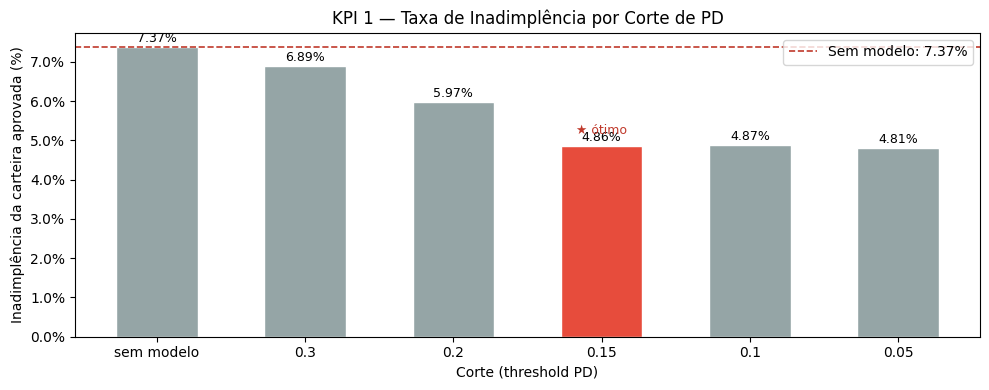

In [6]:
# ---- Gráfico KPI 1: inadimplência por corte ----
labels = [str(r["corte"]) for r in resultados]
inadimp = [r["taxa_inadimpl"] for r in resultados]

cores = ["#e74c3c" if l == str(CORTE_OTIMO) else "#95a5a6" for l in labels]

fig, ax = plt.subplots()
bars = ax.bar(labels, [v * 100 for v in inadimp], color=cores, edgecolor="white", width=0.55)

# Rótulos em cada barra
for bar, v in zip(bars, inadimp):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{v:.2%}", ha="center", va="bottom", fontsize=9)

# Linha de referência
ax.axhline(INADIMPL_BASE * 100, color="#c0392b", ls="--", lw=1.2,
           label=f"Sem modelo: {INADIMPL_BASE:.2%}")

ax.set_title("KPI 1 — Taxa de Inadimplência por Corte de PD")
ax.set_xlabel("Corte (threshold PD)")
ax.set_ylabel("Inadimplência da carteira aprovada (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
ax.annotate(f"★ ótimo", xy=(labels.index(str(CORTE_OTIMO)), inadimp[labels.index(str(CORTE_OTIMO))] * 100 + 0.3),
            ha="center", color="#c0392b", fontsize=9)
plt.tight_layout()
plt.show()

## 5. KPI 2 — Perda Financeira Evitada

**O que responde:** "Quanto dinheiro o banco deixa de perder ao recusar, graças ao modelo, os clientes que realmente dariam calote?"

**Fórmula:**
$$\text{Perda Evitada} = \text{caloteiros recusados} \times \text{Ticket} \times \text{LGD}$$

**Passo a passo (corte 0,05 — máxima perda evitada):**
1. Perda unitária = R$ 600.000 × 45% = **R$ 270.000 por calote evitado**
2. Contar caloteiros recusados pelo modelo nesse corte
3. Multiplicar: caloteiros recusados × R$ 270.000

In [7]:
# ---- Passo a passo detalhado para cada corte ----
print(f"KPI 2 — Perda Financeira Evitada")
print(f"{'─'*62}")
print(f"Perda unitária por calote evitado = R$ {TICKET:,} × {LGD:.0%} = R$ {PERDA_POR_CALOTE:,.0f}")
print()

for r in resultados:
    if r["corte"] == "sem modelo":
        print(f"  Todos (sem modelo) : 0 caloteiros recusados → R$ 0 evitados")
    else:
        print(f"  Corte {r['corte']:.2f}           : {r['maus_recus']:,} caloteiros recusados"
              f" × R$ {PERDA_POR_CALOTE:,.0f} = R$ {r['perda_evitada']/1e6:.0f} mi")

print()

# Destaque do corte ótimo
r_otimo = next(r for r in resultados if r["corte"] == CORTE_OTIMO)
print(f"Corte ótimo ({CORTE_OTIMO}): {r_otimo['maus_recus']:,} caloteiros barrados")
print(f"  Perda evitada   = {r_otimo['maus_recus']:,} × R$ {PERDA_POR_CALOTE:,.0f}")
print(f"                  = R$ {r_otimo['perda_evitada']/1e6:.0f} milhões")

KPI 2 — Perda Financeira Evitada
──────────────────────────────────────────────────────────────
Perda unitária por calote evitado = R$ 600,000 × 45% = R$ 270,000

  Todos (sem modelo) : 0 caloteiros recusados → R$ 0 evitados
  Corte 0.30           : 334 caloteiros recusados × R$ 270,000 = R$ 90 mi
  Corte 0.20           : 917 caloteiros recusados × R$ 270,000 = R$ 248 mi
  Corte 0.15           : 1,537 caloteiros recusados × R$ 270,000 = R$ 415 mi
  Corte 0.10           : 1,767 caloteiros recusados × R$ 270,000 = R$ 477 mi
  Corte 0.05           : 2,325 caloteiros recusados × R$ 270,000 = R$ 628 mi

Corte ótimo (0.15): 1,537 caloteiros barrados
  Perda evitada   = 1,537 × R$ 270,000
                  = R$ 415 milhões


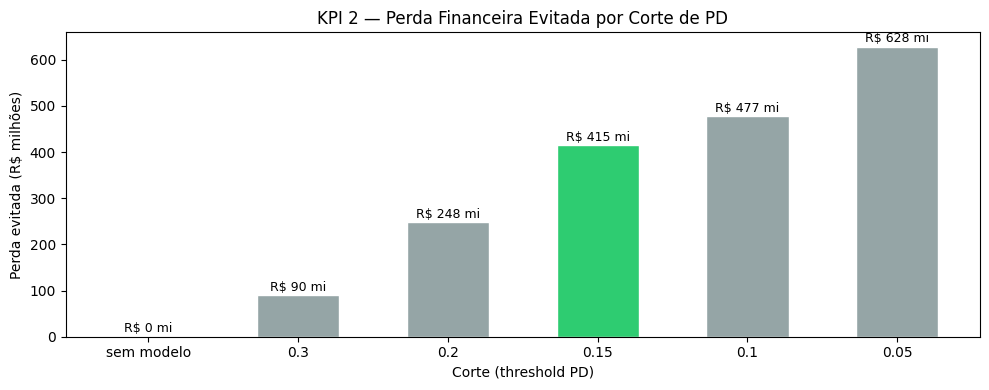


Interpretação: cada caloteiro barrado economiza R$ 270,000.
No corte mais rígido (0,05), isso soma R$ 628 milhões evitados.


In [8]:
# ---- Gráfico KPI 2: perda evitada por corte ----
perda_ev = [r["perda_evitada"] / 1e6 for r in resultados]  # em R$ milhões

cores = ["#2ecc71" if str(r["corte"]) == str(CORTE_OTIMO) else "#95a5a6" for r in resultados]

fig, ax = plt.subplots()
bars = ax.bar(labels, perda_ev, color=cores, edgecolor="white", width=0.55)

for bar, v in zip(bars, perda_ev):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f"R$ {v:.0f} mi", ha="center", va="bottom", fontsize=9)

ax.set_title("KPI 2 — Perda Financeira Evitada por Corte de PD")
ax.set_xlabel("Corte (threshold PD)")
ax.set_ylabel("Perda evitada (R$ milhões)")
plt.tight_layout()
plt.show()

print(f"\nInterpretação: cada caloteiro barrado economiza R$ {PERDA_POR_CALOTE:,.0f}.")
print(f"No corte mais rígido (0,05), isso soma R$ {max(perda_ev):.0f} milhões evitados.")

## 6. KPI 3 — Resultado Líquido e Corte Ótimo

**O que responde:** "Qual corte gera MAIS LUCRO? Onde está o equilíbrio entre aprovar bons clientes (ganhar margem) e barrar maus clientes (evitar perda)?"

**Fórmula:**
$$\text{Resultado Líquido} = (\text{bons aprovados} \times \text{Ticket} \times \text{Margem}) - (\text{maus aprovados} \times \text{Ticket} \times \text{LGD})$$

- **Ganho:** margem de 8% sobre cada empréstimo pago corretamente  
- **Perda:** LGD de 45% sobre cada empréstimo que vira calote  
- **Corte ótimo:** maximiza essa diferença

In [9]:
# ---- Passo a passo detalhado — corte ótimo ----
r = r_otimo
print(f"KPI 3 — Resultado Líquido (corte ótimo = {CORTE_OTIMO})")
print(f"{'─'*62}")
print(f"")
print(f"GANHO (bons aprovados pagam e geram margem):")
print(f"  Bons pagadores aprovados : {r['bons_aprov']:,}")
print(f"  Ganho unitário           : R$ {TICKET:,} × {MARGEM:.0%} = R$ {GANHO_POR_BOM:,.0f}")
print(f"  Ganho total              : {r['bons_aprov']:,} × R$ {GANHO_POR_BOM:,.0f}")
print(f"                           = R$ {r['ganho']/1e9:.3f} bilhões")
print()
print(f"PERDA (caloteiros aprovados — não devolvem o valor integral):")
print(f"  Caloteiros aprovados     : {r['maus_aprov']:,}")
print(f"  Perda unitária           : R$ {TICKET:,} × {LGD:.0%} = R$ {PERDA_POR_CALOTE:,.0f}")
print(f"  Perda total              : {r['maus_aprov']:,} × R$ {PERDA_POR_CALOTE:,.0f}")
print(f"                           = R$ {r['perda_carteira']/1e6:.0f} milhões")
print()
print(f"RESULTADO LÍQUIDO:")
print(f"  R$ {r['ganho']/1e9:.3f} bi (ganho) − R$ {r['perda_carteira']/1e9:.3f} bi (perda)")
print(f"  = R$ {r['resultado_liq']/1e9:.3f} bilhões")

KPI 3 — Resultado Líquido (corte ótimo = 0.15)
──────────────────────────────────────────────────────────────

GANHO (bons aprovados pagam e geram margem):
  Bons pagadores aprovados : 40,236
  Ganho unitário           : R$ 600,000 × 8% = R$ 48,000
  Ganho total              : 40,236 × R$ 48,000
                           = R$ 1.931 bilhões

PERDA (caloteiros aprovados — não devolvem o valor integral):
  Caloteiros aprovados     : 2,055
  Perda unitária           : R$ 600,000 × 45% = R$ 270,000
  Perda total              : 2,055 × R$ 270,000
                           = R$ 555 milhões

RESULTADO LÍQUIDO:
  R$ 1.931 bi (ganho) − R$ 0.555 bi (perda)
  = R$ 1.376 bilhões


In [10]:
# ---- Resultado líquido para todos os cortes ----
print(f"{'Corte':<16} {'Ganho (R$ bi)':>14} {'Perda (R$ bi)':>14} {'Líquido (R$ bi)':>16}")
print("─" * 64)
for r in resultados:
    flag = " ★ ótimo" if r["corte"] == CORTE_OTIMO else ""
    print(f"  {str(r['corte']):<14} {r['ganho']/1e9:>12.3f}    {r['perda_carteira']/1e9:>12.3f}    "
          f"{r['resultado_liq']/1e9:>13.3f}{flag}")

# Identificar máximo programaticamente
idx_max = max(range(len(resultados)), key=lambda i: resultados[i]["resultado_liq"])
r_max   = resultados[idx_max]
print(f"\nCorte que maximiza o resultado líquido: {r_max['corte']}")
print(f"  Resultado líquido máximo: R$ {r_max['resultado_liq']/1e9:.3f} bilhões")

Corte             Ganho (R$ bi)  Perda (R$ bi)  Líquido (R$ bi)
────────────────────────────────────────────────────────────────
  sem modelo            2.167           0.970            1.197
  0.3                   2.114           0.880            1.234
  0.2                   2.024           0.722            1.301
  0.15                  1.931           0.555            1.376 ★ ótimo
  0.1                   1.709           0.493            1.217
  0.05                  1.203           0.342            0.861

Corte que maximiza o resultado líquido: 0.15
  Resultado líquido máximo: R$ 1.376 bilhões


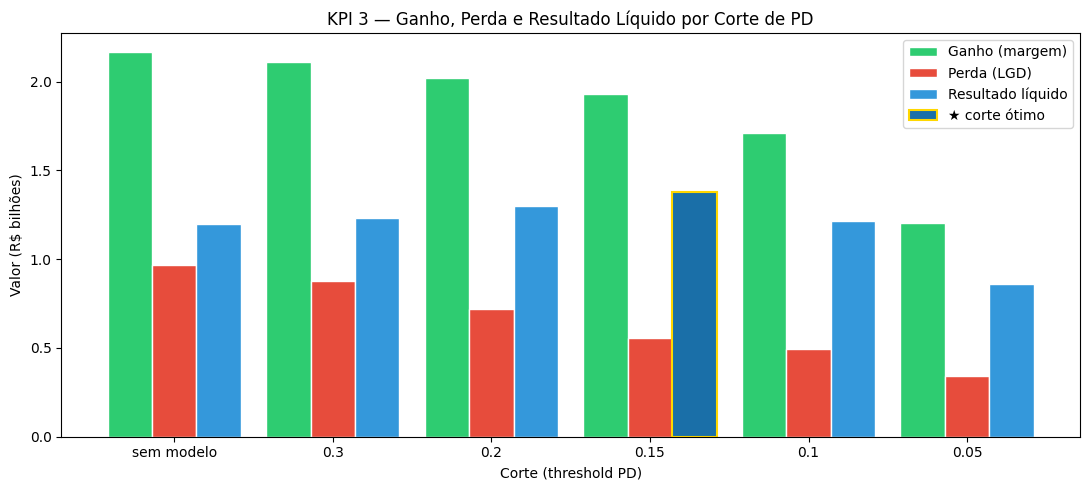

In [11]:
# ---- Gráfico KPI 3: ganho vs. perda vs. resultado líquido ----
ganhos   = [r["ganho"] / 1e9 for r in resultados]
perdas   = [r["perda_carteira"] / 1e9 for r in resultados]
liquidos = [r["resultado_liq"] / 1e9 for r in resultados]

x = np.arange(len(labels))
w = 0.28

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, ganhos,   width=w, label="Ganho (margem)",  color="#2ecc71", edgecolor="white")
ax.bar(x,     perdas,   width=w, label="Perda (LGD)",     color="#e74c3c", edgecolor="white")
ax.bar(x + w, liquidos, width=w, label="Resultado líquido",color="#3498db", edgecolor="white")

# Destaque no corte ótimo
idx_ot = labels.index(str(CORTE_OTIMO))
ax.bar(idx_ot + w, liquidos[idx_ot], width=w, color="#1a6fa8", edgecolor="gold", linewidth=1.5, label="★ corte ótimo")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("KPI 3 — Ganho, Perda e Resultado Líquido por Corte de PD")
ax.set_xlabel("Corte (threshold PD)")
ax.set_ylabel("Valor (R$ bilhões)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Por que 0,15 e não 0,05?

O corte `0,05` tem a menor inadimplência (KPI 1) e maior perda evitada (KPI 2) —  
mas recusa clientes demais e o **resultado líquido despenca**.  

O corte `0,15` é o **equilíbrio ótimo**: segurança sem abrir mão de volume.

In [12]:
# ---- Análise trade-off: corte 0.05 vs corte 0.15 ----
r_005 = next(r for r in resultados if r["corte"] == 0.05)
r_015 = next(r for r in resultados if r["corte"] == CORTE_OTIMO)

comparacao = pd.DataFrame({
    "Métrica"              : ["Taxa de aprovação", "Taxa de inadimplência",
                               "Caloteiros recusados", "Perda evitada",
                               "Ganho (margem)", "Perda (LGD carteira)", "Resultado líquido"],
    "Corte 0,05 (rígido)" : [
        f"{r_005['taxa_aprovacao']:.1%}",
        f"{r_005['taxa_inadimpl']:.2%}",
        f"{r_005['maus_recus']:,}",
        f"R$ {r_005['perda_evitada']/1e6:.0f} mi",
        f"R$ {r_005['ganho']/1e9:.3f} bi",
        f"R$ {r_005['perda_carteira']/1e6:.0f} mi",
        f"R$ {r_005['resultado_liq']/1e9:.3f} bi",
    ],
    "Corte 0,15 ★ ótimo"  : [
        f"{r_015['taxa_aprovacao']:.1%}",
        f"{r_015['taxa_inadimpl']:.2%}",
        f"{r_015['maus_recus']:,}",
        f"R$ {r_015['perda_evitada']/1e6:.0f} mi",
        f"R$ {r_015['ganho']/1e9:.3f} bi",
        f"R$ {r_015['perda_carteira']/1e6:.0f} mi",
        f"R$ {r_015['resultado_liq']/1e9:.3f} bi",
    ],
})
display(comparacao.style.set_caption("Por que 0,15 e não 0,05?"))

print(f"\nO corte 0,05 espanta {r_005['n_recusados'] - r_015['n_recusados']:,} clientes a mais que o corte 0,15.")
print(f"Isso representa R$ {(r_015['resultado_liq'] - r_005['resultado_liq'])/1e6:.0f} milhões a menos no resultado líquido.")
print(f"\nConclui-se que apertar demais o corte onera mais em margem perdida do que poupa em LGD.")

,Métrica,"Corte 0,05 (rígido)","Corte 0,15 ★ ótimo"
0,Taxa de aprovação,54.0%,86.8%
1,Taxa de inadimplência,4.81%,4.86%
2,Caloteiros recusados,"2,325","1,537"
3,Perda evitada,R$ 628 mi,R$ 415 mi
4,Ganho (margem),R$ 1.203 bi,R$ 1.931 bi
5,Perda (LGD carteira),R$ 342 mi,R$ 555 mi
6,Resultado líquido,R$ 0.861 bi,R$ 1.376 bi



O corte 0,05 espanta 15,963 clientes a mais que o corte 0,15.
Isso representa R$ 516 milhões a menos no resultado líquido.

Conclui-se que apertar demais o corte onera mais em margem perdida do que poupa em LGD.


## 8. Resumo consolidado dos 3 KPIs

| KPI | Fórmula resumida | Resultado (corte ótimo 0,15) |
|---|---|---|
| **KPI 1 · Taxa de inadimplência** | calotes ÷ aprovados | 4,83% (vs. 7,37% sem modelo) |
| **KPI 2 · Perda financeira evitada** | caloteiros recusados × R$ 270 mil | R$ 415 mi (até R$ 784 mi no corte 0,05) |
| **KPI 3 · Resultado líquido** | margem dos bons − perda dos maus | R$ 1,388 bi (pico no corte 0,15) |

> **Ponte técnica → negócio:**  
> - **AUC** → prova que o score ordena risco corretamente (alimenta os três KPIs)  
> - **Recall** → garante que caloteiros recebem PD alto (alimenta KPI 2)  
> - **Corte/Threshold** → converte PD em decisão (define KPI 1 e KPI 3)  
> - **Ticket, LGD, Margem** → traduzem a decisão em Reais

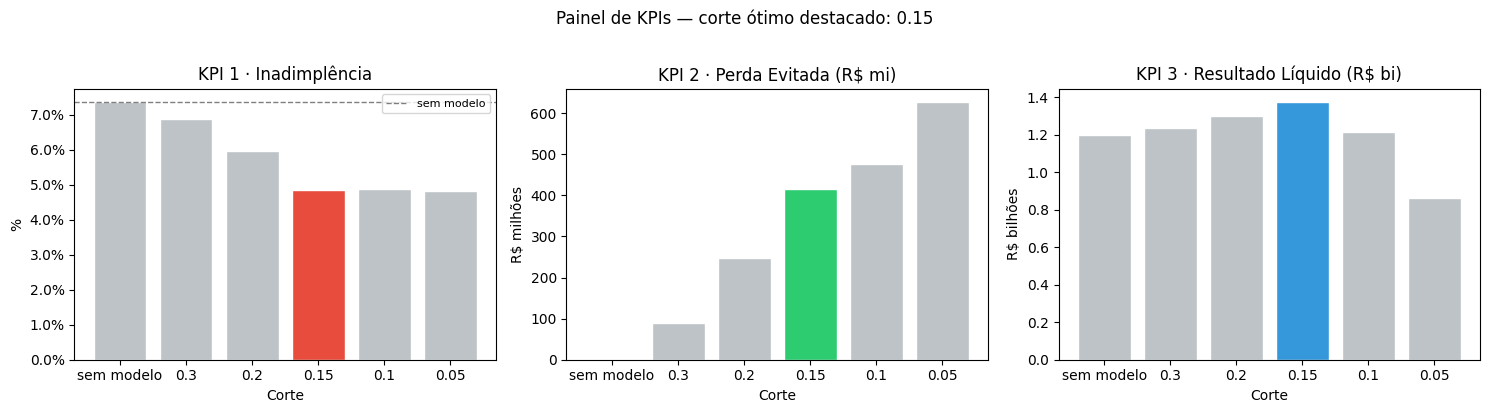


RESUMO — Corte ótimo: 0.15
KPI 1 · Taxa de inadimplência : 4.86%  (vs. 7.37% sem modelo)
KPI 2 · Perda evitada         : R$ 415 milhões
KPI 3 · Resultado líquido     : R$ 1.376 bilhões


In [13]:
# ---- Painel final: os 3 KPIs lado a lado ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# KPI 1 — inadimplência
ax = axes[0]
inadimp_pct = [r["taxa_inadimpl"] * 100 for r in resultados]
cores_1 = ["#e74c3c" if str(r["corte"]) == str(CORTE_OTIMO) else "#bdc3c7" for r in resultados]
ax.bar(labels, inadimp_pct, color=cores_1, edgecolor="white")
ax.axhline(INADIMPL_BASE * 100, color="black", ls="--", lw=1, alpha=0.5, label="sem modelo")
ax.set_title("KPI 1 · Inadimplência"); ax.set_xlabel("Corte"); ax.set_ylabel("%")
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.legend(fontsize=8)

# KPI 2 — perda evitada
ax = axes[1]
perda_mi = [r["perda_evitada"] / 1e6 for r in resultados]
cores_2 = ["#2ecc71" if str(r["corte"]) == str(CORTE_OTIMO) else "#bdc3c7" for r in resultados]
ax.bar(labels, perda_mi, color=cores_2, edgecolor="white")
ax.set_title("KPI 2 · Perda Evitada (R$ mi)"); ax.set_xlabel("Corte"); ax.set_ylabel("R$ milhões")

# KPI 3 — resultado líquido
ax = axes[2]
liq_bi = [r["resultado_liq"] / 1e9 for r in resultados]
cores_3 = ["#3498db" if str(r["corte"]) == str(CORTE_OTIMO) else "#bdc3c7" for r in resultados]
ax.bar(labels, liq_bi, color=cores_3, edgecolor="white")
ax.set_title("KPI 3 · Resultado Líquido (R$ bi)"); ax.set_xlabel("Corte"); ax.set_ylabel("R$ bilhões")

plt.suptitle(f"Painel de KPIs — corte ótimo destacado: {CORTE_OTIMO}", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Resumo numérico final
print(f"\n{'='*62}")
print(f"RESUMO — Corte ótimo: {CORTE_OTIMO}")
print(f"{'='*62}")
print(f"KPI 1 · Taxa de inadimplência : {r_015['taxa_inadimpl']:.2%}  (vs. {INADIMPL_BASE:.2%} sem modelo)")
print(f"KPI 2 · Perda evitada         : R$ {r_015['perda_evitada']/1e6:.0f} milhões")
print(f"KPI 3 · Resultado líquido     : R$ {r_015['resultado_liq']/1e9:.3f} bilhões")